## Another Neighbourhood Feature: Avg Neighbour Income
On top of the Komail's avg_nb_price feature, I've added avg_nb_income which is the average income of neighbouring areas. 
Price of house tells us what people paid and their income tells us what people earn, so together they give the model two different but related angles on the same neighbourhood. Both of these features have high correlation with the data too.

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

In [ ]:
# Based on Komail's code in Part_4_Neighbourhood_Features.ipynb
#Load data, split into train/test, then scale features

housing = fetch_california_housing(as_frame=True)
X = housing.data
Y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=456
)

scale = StandardScaler()

X_train_scaled = pd.DataFrame(
    scale.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scale.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("done setting up data")
print("train size:", X_train.shape, "test size:", X_test.shape)

In [ ]:
# Based on Komail's code in Part_4_Neighbourhood_Features.ipynb
# get coords and find nearest neighbours, then make a feature from avg neighbour prices

coords_train = X_train[["Latitude", "Longitude"]].values
coords_test  = X_test[["Latitude", "Longitude"]].values

k = 10
nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
nn.fit(coords_train)

dist_train, idx_train = nn.kneighbors(coords_train)
dist_test,  idx_test  = nn.kneighbors(coords_test)

y_train_arr = y_train.values

avg_nb_price_train = np.array([y_train_arr[idx].mean() for idx in idx_train])
avg_nb_price_test  = np.array([y_train_arr[idx].mean() for idx in idx_test])

print("done making avg neighbour price feature")

In [4]:
# make a new feature using avg neighbour income instead of price

medinc_train_arr = X_train['MedInc'].values

avg_nb_income_train = np.array([medinc_train_arr[idx].mean() for idx in idx_train])
avg_nb_income_test  = np.array([medinc_train_arr[idx].mean() for idx in idx_test])

print("done making avg neighbour income feature")

print("train data:")
print("min:", round(avg_nb_income_train.min(), 2), 
      "max:", round(avg_nb_income_train.max(), 2), 
      "mean:", round(avg_nb_income_train.mean(), 2))

print("test data:")
print("min:", round(avg_nb_income_test.min(), 2), 
      "max:", round(avg_nb_income_test.max(), 2), 
      "mean:", round(avg_nb_income_test.mean(), 2))

done making avg neighbour income feature
train data:
min: 1.21 max: 14.27 mean: 3.78
test data:
min: 1.21 max: 13.27 mean: 3.82


In [5]:
# add the new features to the scaled data and scale them as well

X_train_final = X_train_scaled.copy()
X_test_final  = X_test_scaled.copy()

# add features
X_train_final['avg_nb_price']  = avg_nb_price_train
X_test_final['avg_nb_price']   = avg_nb_price_test

X_train_final['avg_nb_income'] = avg_nb_income_train
X_test_final['avg_nb_income']  = avg_nb_income_test

# scale the new columns
nb_scaler = StandardScaler()

X_train_final[['avg_nb_price', 'avg_nb_income']] = nb_scaler.fit_transform(
    X_train_final[['avg_nb_price', 'avg_nb_income']]
)

X_test_final[['avg_nb_price', 'avg_nb_income']] = nb_scaler.transform(
    X_test_final[['avg_nb_price', 'avg_nb_income']]
)

print("final shapes:")
print("train:", X_train_final.shape)
print("test:", X_test_final.shape)

print("features:", list(X_train_final.columns))

final shapes:
train: (16512, 10)
test: (4128, 10)
features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'avg_nb_price', 'avg_nb_income']


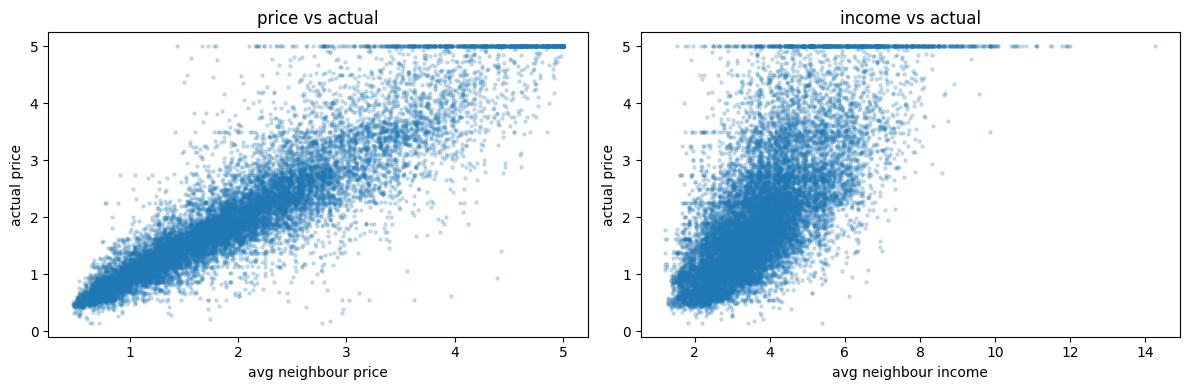

corr price vs actual: 0.9107
corr income vs actual: 0.7169


In [7]:
#Visualising both features vs actual price to see relationships

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# avg neighbour price vs actual
axes[0].scatter(avg_nb_price_train, y_train, alpha=0.2, s=5)
axes[0].set_xlabel('avg neighbour price')
axes[0].set_ylabel('actual price')
axes[0].set_title('price vs actual')

# avg neighbour income vs actual
axes[1].scatter(avg_nb_income_train, y_train, alpha=0.2, s=5)
axes[1].set_xlabel('avg neighbour income')
axes[1].set_ylabel('actual price')
axes[1].set_title('income vs actual')

plt.tight_layout()
plt.show()

# correlations
corr_price  = pd.Series(avg_nb_price_train).corr(y_train.reset_index(drop=True))
corr_income = pd.Series(avg_nb_income_train).corr(y_train.reset_index(drop=True))

print("corr price vs actual:", round(corr_price, 4))
print("corr income vs actual:", round(corr_income, 4))

Both features correlate well with the actual house price (0.91 and 0.72) which confirms they're
both useful. The difference in correlation values shows they're not just measuring
the same thing and that income adds something extra on top of price.

## Notes for model 2 builder

use these variables for the improved model:

* `X_train_final` = training input data with 10 features total
* `X_test_final` = test input data with the same 10 features
* `y_train` and `y_test` = target house prices, unchanged

the 10 features are:

* the original 8 features
* `avg_nb_price`
* `avg_nb_income`

all input features in `X_train_final` and `X_test_final` have been scaled already so they are ready to go into the model.
